# Laboratorul 8

Rezolvați exercițiile de mai jos în celulele care v-au fost puse la dispoziție. La final, rulați tot notebook-ul și asigurați-vă că nu aveți erori. Salvați fișierul și încărcați-l în assignment-ul de Teams corespunzător grupei voastre.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

## Exercițiul 1

Care este **frecvența de eșantionare** a semnalului de trafic? (revedeți secțiunea pentru detalii despre cum a fost achiziționat acesta)

1 esantion/ora

## Exercițiul 2

Ce **interval de timp** acoperă eșantioanele din fișier?

18288 ore = 762 zile = 2.09 ani

## Exercițiul 3

Presupunând că semnalul a fost eșantionat **corect** (fără aliere) și **optim**, care este **frecvența maximă** prezentă în semnal?

$$
f_{\text{max}} = \frac{F_s}{2} = 1/2 = 0.5
$$

**Frecventa maxima** prezenta in semnal este de 0.5 esantioane/ora


## Exercițiul 4

Utilizați funcția `np.fft.rfft(x)` pentru a calcula **transformata Fourier** a semnalului și afișați grafic **modulul transformatei**.

Deoarece valorile pe care le veți calcula sunt în Hz, este important să definiți corect frecvența de eșantionare (astfel încât valorile de frecvențe pe care le obțineți utilizând ultima secvență de cod din ghidul Python din îndrumar să aibă o interpretare corectă din punct de vedere fizic).

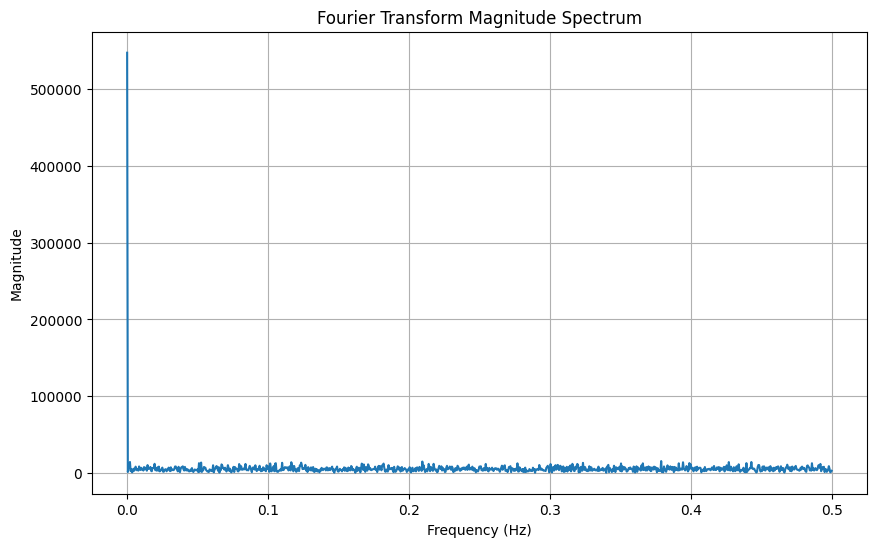

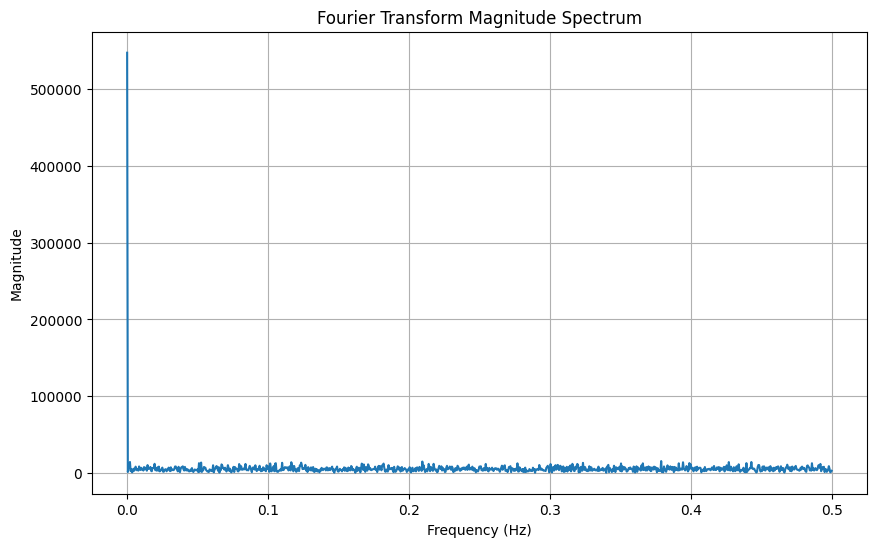

In [16]:
import numpy as np
import matplotlib.pyplot as plt

traffic_data = np.genfromtxt('traffic.csv', delimiter=',')

sampling_frequency = 1

fft_result = np.fft.rfft(traffic_data)

num_points = len(traffic_data)

frequencies = np.fft.rfftfreq(num_points, d=1/sampling_frequency)

magnitude = np.abs(fft_result)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, magnitude)
plt.title('Fourier Transform Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()
import numpy as np
import matplotlib.pyplot as plt

traffic_data = np.genfromtxt('traffic.csv', delimiter=',')

sampling_frequency = 1

fft_result = np.fft.rfft(traffic_data)

num_points = len(traffic_data)

frequencies = np.fft.rfftfreq(num_points, d=1/sampling_frequency)

magnitude = np.abs(fft_result)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, magnitude)
plt.title('Fourier Transform Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()


## Exercițiul 5

Prezintă acest semnal o **componentă continuă**? Dacă da, eliminați-o și afișați semnalul rezultat. Dacă nu, specificați cum ați determinat acest fapt.

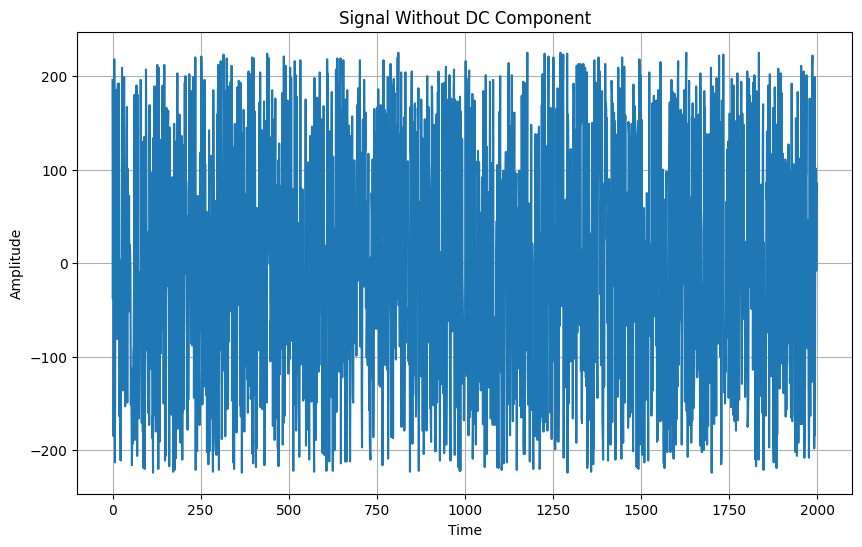

In [17]:
import numpy as np
import matplotlib.pyplot as plt

signal_data = np.genfromtxt('traffic.csv', delimiter=',')
signal = signal_data

sampling_frequency = 1

fft_result = np.fft.rfft(signal)

num_samples = len(signal)
frequencies = np.fft.rfftfreq(num_samples, d=1/sampling_frequency)

if np.abs(fft_result[0]) > 1e-6:
    fft_result[0] = 0

signal_no_dc = np.fft.irfft(fft_result)

plt.figure(figsize=(10, 6))
plt.plot(signal_no_dc)
plt.title('Signal Without DC Component')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


## Exercițiul 6

Care sunt frecvențele principale conținute în semnal, așa cum apar ele în transformata Fourier? Mai exact, determinați **primele 4 cele mai mari valori** ale modulului transformatei și specificați căror frecvențe (în Hz) le corespund. Căror fenomene periodice din semnal se asociază fiecare?

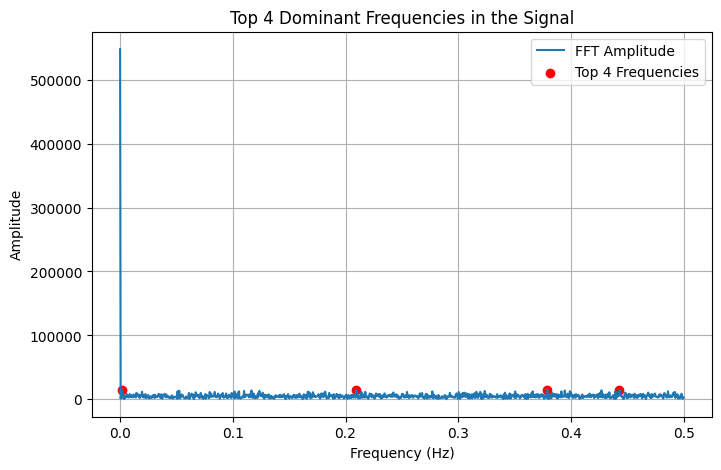

In [18]:
import numpy as np
import matplotlib.pyplot as plt

signal_data = np.genfromtxt('traffic.csv', delimiter=',')
signal = signal_data

sampling_frequency = 1

fft_transform = np.fft.rfft(signal)
fft_amplitude = np.abs(fft_transform)

frequencies = np.fft.rfftfreq(len(signal), d=1/sampling_frequency)

sorted_indices = np.argsort(fft_amplitude)[::-1]

sorted_indices = sorted_indices[1:]

top_indices = sorted_indices[:4]
dominant_frequencies = frequencies[top_indices]
dominant_amplitudes = fft_amplitude[top_indices]

plt.figure(figsize=(8, 5))
plt.plot(frequencies, fft_amplitude, label='FFT Amplitude')
plt.scatter(dominant_frequencies, dominant_amplitudes, color='red', label='Top 4 Frequencies')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Top 4 Dominant Frequencies in the Signal')
plt.legend()
plt.grid(True)
plt.show()


## Exercițiul 7

Începând de la un eșantion ales de voi (după cel al 1000-lea), reprezentați, pe un grafic separat, **o lună de trafic**. Alegeți eșantionul de start astfel încât reprezentarea să înceapă într-o **zi de luni**.

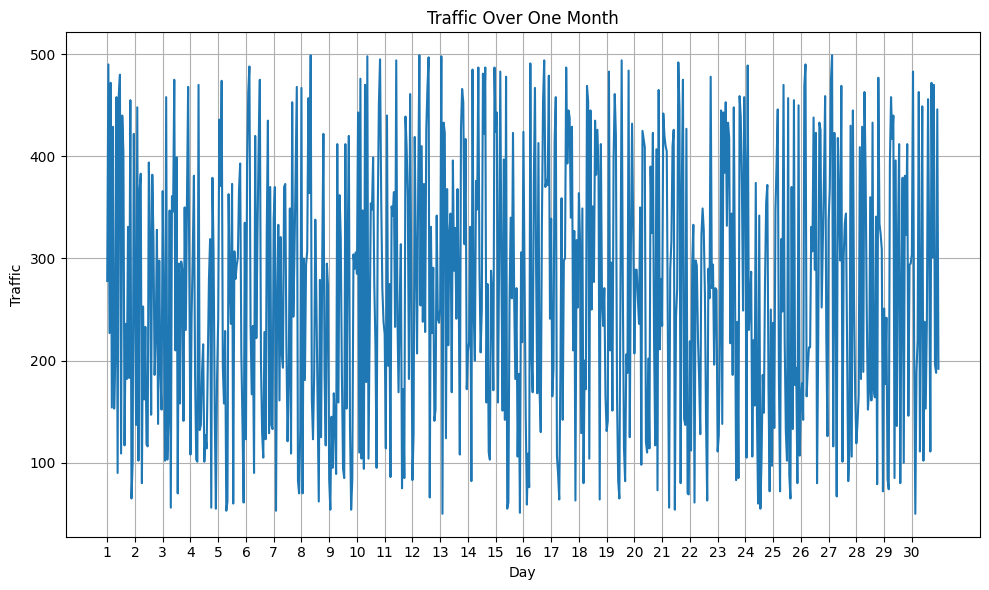

In [19]:
import numpy as np
import matplotlib.pyplot as plt

traffic_data = np.genfromtxt('traffic.csv', delimiter=',')

start_sample = 1000

while start_sample % 7 != 0:
    start_sample += 1

end_sample = start_sample + 30 * 24

monthly_data = traffic_data[start_sample:end_sample]

plt.figure(figsize=(10, 6))
plt.plot(monthly_data)
plt.title('Traffic Over One Month')
plt.xlabel('Day')
plt.ylabel('Traffic')
plt.grid(True)
plt.xticks(np.arange(0, len(monthly_data), step=24), labels=[f'{i+1}' for i in range(30)])
plt.tight_layout()
plt.show()


## Exercițiul 8

Nu se cunoaște data la care a început măsurarea acestui semnal. Concepeți o **metodă** (descrieți în cuvinte) prin care să determinați, doar analizând semnalul în timp, această dată. Comentați ce neajunsuri ar putea avea soluția propusă și care sunt factorii de care depinde acuratețea ei.

## Metoda propusa
Pentru a determina data la care a inceput masurarea semnalului, putem analiza periodicitatea si alte caracteristici temporale ale semnalului. Metoda implica urmatorii pasi:

1. **Analiza Transformatei Fourier (FFT):**  
   Se identifica frecventele dominante prin aplicarea FFT pe semnal. Acest pas permite identificarea unei posibile periodicitati.

2. **Detectarea unui tipar repetitiv:**  
   Daca semnalul prezinta o periodicitate (cum ar fi cicluri zilnice sau saptamanale), se poate presupune ca masuratorile incep de la un punct fix in ciclul identificat. Analiza se bazeaza pe varfurile semnalului si pe pozitia lor relativa fata de inceputul semnalului.

3. **Corelarea cu alte date (daca este posibil):**  
   Compararea semnalului cu alte surse externe de date (cum ar fi trafic mediu zilnic sau alte informatii temporale) poate ajuta la confirmarea alinierii corecte.

## Neajunsurile metodei
1. **Prezenta zgomotului:**  
   Un semnal afectat de zgomot poate face dificila identificarea unei periodicitati clare. Este nevoie de preprocesare pentru eliminarea zgomotului.

2. **Semnal neperiodic:**  
   In absenta unei periodicitati evidente, metoda poate esua sau poate oferi rezultate ambigue.

3. **Rezolutia analizelor:**  
   Rezolutia identificarii frecventelor dominante depinde de lungimea semnalului analizat si de rata de esantionare.

## Factori care influenteaza acuratetea
1. **Calitatea semnalului:**  
   Semnalele curate si lungi permit rezultate mai precise. Zgomotul si intreruperile pot distorsiona analiza.

2. **Dominanta frecventelor:**  
   Daca semnalul contine mai multe frecvente dominante, pot aparea ambiguitati in interpretarea rezultatelor.

3. **Preprocesarea semnalului:**  
   Operatiuni precum eliminarea zgomotului si normalizarea pot contribui semnificativ la imbunatatirea preciziei analizelor.

Aceasta metoda permite aproximarea datei initiale bazandu-se pe analiza semnalului, insa interpretarea rezultatelor trebuie sa fie realizata cu atentie, tinand cont de limitarile si factorii mentionati.
